In [15]:
import pandas as pd
import numpy as np
import gc
import os
from tqdm import tqdm
from pathlib import Path

from sklearn.model_selection import train_test_split
import torch
from PIL import Image
from open_clip import create_model_from_pretrained, get_tokenizer, create_model_and_transforms
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from transformers import AutoModel, AutoTokenizer, AutoProcessor, AutoModelForMaskedLM
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from torch.utils.data import TensorDataset, DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import plotly as px
from plotly import graph_objects as go
from sklearn.preprocessing import StandardScaler
from peft import LoraConfig, get_peft_model
from torch.amp import autocast, GradScaler

from health_multimodal.image.inference_engine import ImageInferenceEngine
from health_multimodal.image.model.pretrained import get_biovil_t_image_encoder
from health_multimodal.image.data.transforms import create_chest_xray_transform_for_inference

In [16]:
pd.options.display.max_columns = None

In [17]:
df_pos = pd.read_csv("./chexpert_matches_sample.csv", index_col=0)
df_pos

,path_to_image,deid_patient_id,report,section_findings,section_impression,section_summary
85986,train/patient20638/study1/view1_frontal.jpg,patient20638,"NARRATIVE:\nEXAM: Chest 1 View August 9th, 200...",NaN,\n \n1.PORTABLE RADIOGRAPH OF THE CHEST DEMONS...,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTIO..."
4080,train/patient01004/study1/view2_lateral.jpg,patient01004,NARRATIVE:\nChest 2 Views 12-13-2004\n \nHisto...,PA and lateral view of the chest demonstrate...,\n \nPROBABLE SMALL LEFT RETROCARDIAC POSTER...,1-NO SIGNIFICANT ABNORMALITY\n \n
214718,train/patient58143/study1/view1_frontal.jpg,patient58143,NARRATIVE:\nPORTABLE CHEST: 7/30/09\nCLINICAL...,NaN,\n 1. RIGHT INTERNAL JUGULAR CENTRAL LINE ...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI..."
578,train/patient00145/study1/view1_frontal.jpg,patient00145,"NARRATIVE:\nExam: Chest 2 Views, 7-30-2017\n \...",NaN,\n \n1.TWO VIEWS OF THE CHEST DEMONSTRATE CARD...,"4-POSSIBLY SIGNIFICANT FINDING, MAY NEED ACTIO..."
20876,train/patient05116/study6/view1_frontal.jpg,patient05116,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 4/21/201...",NaN,\n \n 1. PORTABLE RADIOGRAPH OBTAINED IN THE ...,"2-ABNORMAL, PREVIOUSLY REPORTED\n \n \n \n"
...,...,...,...,...,...,...
58749,train/patient14233/study6/view1_frontal.jpg,patient14233,"NARRATIVE:\nEXAM: Chest 1 View, 3/27/2012\n \n...",NaN,"\n \n1.ET TUBE, NG TUBE, FEEDING TUBE, LEFT PI...","2-ABNORMAL, PREVIOUSLY REPORTED\n \n"
206588,train/patient53101/study1/view1_frontal.jpg,patient53101,"NARRATIVE:\nCHEST: One view chest, 03/14/20 53...",\nThere are low lung volumes with indistinct p...,\n1. MILD INTERSTITIAL PULMONARY EDEMA.\n2. MI...,"4: POSSIBLE SIGNIFICANT FINDINGS, MAY NEED AC..."
221230,train/patient62732/study1/view1_frontal.jpg,patient62732,NARRATIVE:\nSINGLE FRONTAL VIEW OF THE CHEST: ...,The left lung base is not well evaluated due...,\n \n 1. MILD INTERSTITIAL EDEMA AND CARDIOM...,"2-ABNORMAL, PREVIOUSLY REPORTED\n \n"
1252,train/patient00300/study1/view1_frontal.jpg,patient00300,"NARRATIVE:\nEXAM: Chest 1 View, 21/5/07\n \nCL...",NaN,\n \n1.TRAUMA RADIOGRAPH OF THE CHEST DEMONSTR...,1-NO SIGNIFICANT ABNORMALITY\nI have personall...


In [47]:
df_neg = pd.read_csv("./chexpert_mismatches_swapping.csv", index_col=0)

In [20]:
df_neg= df_neg.iloc[:, :6]
df_neg

,path_to_image,deid_patient_id,report,section_findings,section_impression,section_summary
0,train/patient57681/study3/view1_frontal.jpg,patient57681,NARRATIVE:\nCHEST TWO VIEWS: 4-29-2018\nCOMPAR...,NaN,\n1. INTERVAL IMPROVEMENT IN AIRSPACE OPACITY ...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI..."
1,train/patient63093/study1/view1_frontal.jpg,patient63093,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nStable positioning of multiple medical su...,\n \n1. Tiny left apical pneumothorax.\n \n2....,NaN
2,train/patient31182/study5/view1_frontal.jpg,patient31182,"NARRATIVE:\nChest 1 View, 3-2-2005\n \nHISTORY...",NaN,\n \n1. TWO FRONTAL VIEWS OF THE CHEST ON 3/2...,"4-POSSIBLE SIGNIFICANT FINDING, MAY NEED ACTI..."
3,train/patient20936/study4/view2_lateral.jpg,patient20936,NARRATIVE:\nSEMIUPRIGHT VIEW OF THE CHEST: 05...,NaN,\n \n 1. REDEMONSTRATION OF POSTSURGICAL CHA...,"4-POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACTI..."
4,train/patient10146/study3/view1_frontal.jpg,patient10146,"NARRATIVE:\nCHEST, ONE VIEW: 5-12-2012 \n \n ...",NaN,\n \n 1. INTERVAL REMOVAL OF THE LEFT CHEST ...,"2 ABNORMAL, PREVIOUSLY REPORTED. \nI have p..."
...,...,...,...,...,...,...
19390,train/patient40560/study1/view1_frontal.jpg,patient40560,NARRATIVE:\nPORTABLE CHEST SINGLE VIEW: 2000/0...,NaN,\n1. SINGLE AP PORTABLE VIEW OF THE CHEST DEMO...,"4 POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACT..."
19391,train/patient33124/study1/view1_frontal.jpg,patient33124,"NARRATIVE:\nEXAM: Chest 2 Views, 11 november 3...",NaN,\n \n1. LUNGS GROSSLY CLEAR. NO EVIDENCE OF A...,"4-POSSIBLE SIGNIFICANT FINDING, MAY NEED ACTI..."
19392,train/patient39067/study6/view1_frontal.jpg,patient39067,NARRATIVE:\nTWO VIEW CHEST X-RAY: 2/14/2001 \...,NaN,\n \n 1. POST STERNOTOMY CHEST WITH EPICARDI...,"2-ABNORMAL, PREVIOUSLY REPORTED.\n \n"
19393,train/patient07956/study1/view1_frontal.jpg,patient07956,NARRATIVE:\nSINGLE AP VIEW OF THE CHEST: 12-1...,NaN,\n \n SINGLE AP VIEW OF THE CHEST IN THE EREC...,"2-ABNORMAL, PREVIOUSLY REPORTED\n \n"


In [23]:
df_pos_sample = df_pos.sample(18000, random_state=42)
df_pos_sample['target'] = 1
df_pos_infer = df_pos.drop(index=df_pos_sample.index)
df_pos_infer['target'] = 1
df_neg_sample = df_neg.sample(18000, random_state=42)
df_neg_sample['target'] = 0
df_neg_infer = df_neg.drop(index=df_neg_sample.index)
df_neg_infer['target'] = 0

In [24]:
sample_dataset = pd.concat([df_pos_sample,df_neg_sample], ignore_index=True)
sample_dataset = sample_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
sample_dataset_infer = pd.concat([df_pos_infer,df_neg_infer], ignore_index=True)
sample_dataset_infer = sample_dataset_infer.sample(frac=1, random_state=42).reset_index(drop=True)

In [26]:
X = sample_dataset.drop(columns=["target"])
y = sample_dataset["target"]

# Split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# BioViL-T model

In [27]:
# Setup device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load the comprehensive BioViL-T repo for Text
model_id = "microsoft/BiomedVLP-BioViL-T"
# Specialized CXR-BERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
text_model = AutoModel.from_pretrained(model_id, trust_remote_code=True).to(device)

text_model.eval()

# Instantiate the BioViL-T Image Engine
image_model = get_biovil_t_image_encoder().to(device)
image_transform = create_chest_xray_transform_for_inference(resize=512, center_crop_size=448)

image_model.eval()

Using device: cuda


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] CXRBertModel LOAD REPORT from: microsoft/BiomedVLP-BioViL-T
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using downloaded and verified file: C:\Users\SMEC\AppData\Local\Temp\biovil_t_image_model_proj_size_128.pt


c:\Users\SMEC\anaconda3\envs\torch_env2_310\lib\site-packages\health_multimodal\image\model\model.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.loa

ImageModel(
  (encoder): MultiImageEncoder(
    (encoder): ResNetHIML(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (rel

In [28]:
# Test of XCR-BERT
def get_text_embeddings(report_text):
    # Tokenize standard CheXpert format
    inputs = tokenizer(
        report_text, 
        padding="max_length", 
        truncation=True, 
        max_length=512, 
        return_tensors="pt"
    ).to(device)
    
    with torch.no_grad():
        #  Get the joint-space projection (128-d vector) for phase 1 similarity matching
        text_embeddings = text_model.get_projected_text_embeddings(
            input_ids=inputs.input_ids, 
            attention_mask=inputs.attention_mask
        )
        
        #  To get the raw token hidden states for Phase 2 (Cross-Attention)
        outputs = text_model(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            return_dict=True
        )
        # Pull out the hidden states sequence
        sequence_outputs = outputs.last_hidden_state
        
    # Normalize joint-space vector for cosine similarity 
    text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)
    return text_embeddings, sequence_outputs

def get_image_embeddings(image_path):
    #Extracts true BioViL-T spatial and global image embeddings.
    raw_image = Image.open(image_path).convert("L")
    processed_tensor = image_transform(raw_image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Get the native image model outputs
        image_outputs = image_model(processed_tensor)
        
        # Pull global 128-d vector and spatial patch tokens
        global_img_emb = image_outputs.projected_global_embedding
        patch_img_emb = image_outputs.projected_patch_embeddings 
        
    # L2 normalize global vector for cosine similarity
    global_img_emb = F.normalize(global_img_emb, p=2, dim=-1)
    return global_img_emb, patch_img_emb


# BioViL Similartity scores prediction

Full raw reports are used.

In [30]:
class BiovilTrainDataset(Dataset):
    def __init__(self, df, base_path="./CheXpert/CheXpert-v1.0-small/"):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_path = self.base_path + self.df.loc[idx, "path_to_image"]
        report = self.df.loc[idx, "report"]
        return img_path, report, idx

# Setup folders to store heavy tensors for Phase 2 Cross-Attention
os.makedirs("./features/image_patches_train", exist_ok=True)
os.makedirs("./features/text_sequences_train", exist_ok=True)

# Initialize dataset and loader
train_dataset = BiovilTrainDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=False)

similarity_scores = np.zeros(len(X_train))

print("Extracting features and calculating similarities...")
for img_paths, reports, indices in tqdm(train_loader):
    img_path = img_paths[0]
    report = reports[0]
    idx = indices[0].item()
    
    # Extract encoded vectors
    img_vector, img_patches = get_image_embeddings(img_path)      # Shape: [1, 128], [1, 128, 14, 14]
    text_vector, text_sequence = get_text_embeddings(report)       # Shape: [1, 128], [1, 512, 768]
    
    # Compute and store similarity score immediately
    sim = torch.mm(img_vector, text_vector.t()).cpu().item()
    similarity_scores[idx] = sim
    
    # Save heavy spatial/token features to disk using the unique index
    # Detach and move to CPU to free up GPU VRAM immediately
    torch.save(img_patches.detach().cpu(), f"./features/image_patches_train/{idx}.pt")
    torch.save(text_sequence.cpu().detach(), f"./features/text_sequences_train/{idx}.pt")

# Write results back to DataFrame
X_train["similarity_score"] = similarity_scores

Extracting features and calculating similarities...


100%|██████████| 28800/28800 [56:01<00:00,  8.57it/s]


Test ROC-AUC Score: 0.8552
Optimal Similarity Threshold: 0.2985
Maximized True Positive Rate (Sensitivity): 0.7807
Minimized False Positive Rate (1 - Specificity): 0.2256


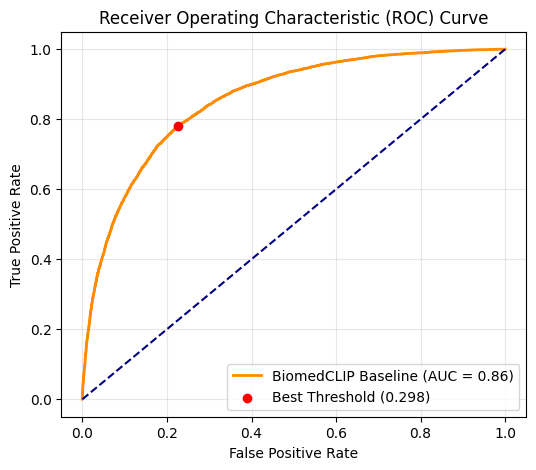

In [31]:

targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()

def evaluate(targets, similarities):
    # Compute ROC-AUC Score
    auc = roc_auc_score(targets, similarities)
    print(f"Test ROC-AUC Score: {auc:.4f}")
    
    # Calculate ROC Curve metrics
    fpr, tpr, thresholds = roc_curve(targets, similarities)
    
    # Find optimal threshold using Youden's J statistic: J = TPR - FPR
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    best_threshold = thresholds[best_idx]
    
    print(f"Optimal Similarity Threshold: {best_threshold:.4f}")
    print(f"Maximized True Positive Rate (Sensitivity): {tpr[best_idx]:.4f}")
    print(f"Minimized False Positive Rate (1 - Specificity): {fpr[best_idx]:.4f}")
    
    # Optional: Plot the ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'BiomedCLIP Baseline (AUC = {auc:.2f})', color='darkorange', lw=2)
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # Random guess line
    plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f'Best Threshold ({best_threshold:.3f})', zorder=5)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return best_threshold

opt_threshold = evaluate(targets, similarities)

In [32]:
def bin_classif_metrics(similarities, targets, opt_threshold, type='Train'):
    # Convert continuous similarity scores into binary predictions (0 or 1)
    predictions = (similarities >= opt_threshold).astype(int)

    # Calculate operational metrics
    accuracy = accuracy_score(targets, predictions)
    precision = precision_score(targets, predictions)  # Out of all predicted matches, how many are real?
    recall = recall_score(targets, predictions)        # Same as Sensitivity / True Positive Rate
    f1 = f1_score(targets, predictions)                # Harmonic mean of Precision and Recall

    # Extract Specificity (True Negative Rate) via Confusion Matrix
    # Matrix format: [[TN, FP], [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(targets, predictions).ravel()
    specificity = tn / (tn + fp)

    # Print the evaluation dashboard
    print(f"--- Operational Metrics at Threshold {opt_threshold} ---")
    print(f"{type} ROC-AUC Score: {roc_auc_score(targets, similarities):.4f}")
    print(f"{type} Accuracy:    {accuracy:.4f}")
    print(f"{type} Precision:   {precision:.4f}")
    print(f"{type} Recall:      {recall:.4f}")
    print(f"{type} F1-Score:    {f1:.4f}")
    print(f"{type} Specificity: {specificity:.4f} (FPR is {1-specificity:.4f})")

In [33]:
class BiovilTestDataset(Dataset):
    def __init__(self, df, base_path="./CheXpert/CheXpert-v1.0-small/"):
        self.df = df.reset_index(drop=True)
        self.base_path = base_path
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        img_path = self.base_path + self.df.loc[idx, "path_to_image"]
        report = self.df.loc[idx, "report"]
        return img_path, report, idx

# Setup folders to store heavy tensors for Phase 2 Cross-Attention
os.makedirs("./features/image_patches_test", exist_ok=True)
os.makedirs("./features/text_sequences_test", exist_ok=True)

# Initialize dataset and loader
test_dataset = BiovilTestDataset(X_test)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

similarity_scores = np.zeros(len(X_test))

print("Extracting features and calculating similarities...")
for img_paths, reports, indices in tqdm(test_loader):
    img_path = img_paths[0]
    report = reports[0]
    idx = indices[0].item()
    
    # Extract encoded vectors
    img_vector, img_patches = get_image_embeddings(img_path)      # Shape: [1, 128], [1, 128, 14, 14]
    text_vector, text_sequence = get_text_embeddings(report)       # Shape: [1, 128], [1, 512, 768]
    
    # Compute and store similarity score immediately
    sim = torch.mm(img_vector, text_vector.t()).cpu().item()
    similarity_scores[idx] = sim
    
    # Save heavy spatial/token features to disk using the unique index
    # Detach and move to CPU to free up GPU VRAM immediately
    torch.save(img_patches.detach().cpu(), f"./features/image_patches_test/{idx}.pt")
    torch.save(text_sequence.cpu().detach(), f"./features/text_sequences_test/{idx}.pt")

# Write results back to DataFrame
X_test["similarity_score"] = similarity_scores

Extracting features and calculating similarities...


100%|██████████| 7200/7200 [14:05<00:00,  8.52it/s]


In [34]:
print("----------Train metrics-------------")
targets = y_train.to_numpy()
similarities = X_train["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Train')

print("----------Test metrics-------------")
targets = y_test.to_numpy()
similarities = X_test["similarity_score"].to_numpy()
bin_classif_metrics(similarities, targets, opt_threshold, type='Test')

----------Train metrics-------------
--- Operational Metrics at Threshold 0.2984555959701538 ---
Train ROC-AUC Score: 0.8552
Train Accuracy:    0.7775
Train Precision:   0.7758
Train Recall:      0.7807
Train F1-Score:    0.7782
Train Specificity: 0.7744 (FPR is 0.2256)
----------Test metrics-------------
--- Operational Metrics at Threshold 0.2984555959701538 ---
Test ROC-AUC Score: 0.8622
Test Accuracy:    0.7837
Test Precision:   0.7786
Test Recall:      0.7931
Test F1-Score:    0.7857
Test Specificity: 0.7744 (FPR is 0.2256)


# BioViL with cross attention + MLP fusion layer

In [35]:
def load_saved_images(idx, type='train'):
    # Load image patches: expected shape [128, 14, 14]
    img_patches = torch.load(f"./features/image_patches_{type}/{idx}.pt", weights_only=True).squeeze(0)
    return img_patches
    
def load_saved_texts(idx, type='train'):    
    # Load text sequence: expected shape [512, 768]
    text_sequence = torch.load(f"./features/text_sequences_{type}/{idx}.pt", weights_only=True).squeeze(0)
    return text_sequence

In [36]:
gc.collect()

6386

In [37]:
cross_att_X_train_img = np.array([load_saved_images(index, "train") for index in tqdm(range(len(X_train)))])
cross_att_X_train_txt = np.array([load_saved_texts(index, "train") for index in tqdm(range(len(X_train)))])

100%|██████████| 28800/28800 [06:09<00:00, 77.90it/s]


In [38]:
cross_att_y_train = y_train.to_numpy()

In [39]:
cross_att_X_train_txt_tensor = torch.from_numpy(cross_att_X_train_txt).float()
cross_att_X_train_img_tensor = torch.from_numpy(cross_att_X_train_img).float()
cross_att_y_train_tensor = torch.from_numpy(cross_att_y_train).float()
cross_att_train_dataset = TensorDataset(cross_att_X_train_img_tensor, cross_att_X_train_txt_tensor, cross_att_y_train_tensor)

In [40]:
cross_att_X_test_img = np.array([load_saved_images(index, "test") for index in tqdm(range(len(X_test)))])
cross_att_X_test_txt = np.array([load_saved_texts(index, "test") for index in tqdm(range(len(X_test)))])
cross_att_y_test = y_test.to_numpy()

100%|██████████| 7200/7200 [01:30<00:00, 79.49it/s]


In [41]:
cross_att_X_test_txt_tensor = torch.from_numpy(cross_att_X_test_txt).float()
cross_att_X_test_img_tensor = torch.from_numpy(cross_att_X_test_img).float()
cross_att_y_test_tensor = torch.from_numpy(cross_att_y_test).float()
cross_att_test_dataset = TensorDataset(cross_att_X_test_img_tensor, cross_att_X_test_txt_tensor, cross_att_y_test_tensor)

cross_att_train_loader = DataLoader(cross_att_train_dataset, batch_size=64, shuffle=True)
cross_att_val_loader = DataLoader(cross_att_test_dataset, batch_size=64, shuffle=False)

In [42]:
class VisualProjectionLayer(nn.Module):
    def __init__(self, img_dim=128, text_dim=768):
        super().__init__()
        # This layer bridges the dimensionality gap (128 -> 768)
        self.projector = nn.Linear(img_dim, text_dim)
        
    def forward(self, img_patches):
        # img_patches is [128, 14, 14]
        # Move channels to the back: [14, 14, 128]
        x = img_patches.permute(0,2, 3, 1)
        
        # Flatten spatial dimensions: [196, 128]
        x = x.flatten(1, 2)
        
        # 3. Project to text dimension: [196, 768]
        projected_visual_tokens = self.projector(x)
        return projected_visual_tokens

In [43]:
class CrossAttentionClassifierBiovil(nn.Module):
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.3):
        super().__init__()
        
        self.projection_layer = VisualProjectionLayer()

        self.cross_attention = nn.MultiheadAttention(
                    embed_dim=embed_dim, 
                    num_heads=num_heads, 
                    dropout=dropout,
                    batch_first=True
                )
        
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)
    
        # Add a small Feed-Forward Network layer (FFN) inside the attention block 
        # This mirrors a true standard Transformer block and stabilizes representation warping
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim)
        )
    
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256), # BatchNorm stabilizes linear scaling transitions!
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )
        
    def forward(self, img_patches, text_tokens):
        img_patches_proj = self.projection_layer(img_patches)
        norm_text = self.layer_norm1(text_tokens)
        # Cross-Attention Core
        attn_output, _ = self.cross_attention(
            query=norm_text, 
            key=img_patches_proj, 
            value=img_patches_proj
        )
        x = (attn_output + text_tokens)
        
        # FFN stabilization step
        x = self.layer_norm2(self.ffn(x)) + x
        
        # Step 3: Max-pooling across sequence dimension 
        # This captures the strongest text-visual features and ignores inactive padding tokens
        x_pooled, _ = torch.max(x, dim=1)
        # Step 4: Predict
        return self.classifier(x_pooled)

In [44]:
def cross_attention_train_biovil(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=100):
    """
    Function to train a PyTorch model with training and validation datasets.

    Parameters:
    model: The neural network model to train.
    train_loader: DataLoader for the training dataset.
    val_loader: DataLoader for the validation dataset.
    criterion: Loss function (e.g., Binary Cross Entropy for classification).
    optimizer: Optimization algorithm (e.g., Adam, SGD).
    epochs: Number of training epochs (default=100).

    Returns:
    history: Dictionary containing loss and accuracy for both training and validation.
    """

    # Dictionary to store training & validation loss and accuracy over epochs
    history = {'loss': [], 'val_loss': [], 'accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):  # Loop over the number of epochs
        model.train()  # Set model to training mode
        total_loss, correct = 0, 0  # Initialize total loss and correct predictions

        # Training loop
        for inputs_img, inputs_txt, labels in train_loader:
            inputs_img = inputs_img.to(device)
            inputs_txt = inputs_txt.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()  # Reset gradients before each batch
            outputs = model(inputs_img, inputs_txt).squeeze(1)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            loss.backward()  # Backpropagation (compute gradients)
            optimizer.step()  # Update model parameters

            total_loss += loss.item()  # Accumulate batch loss
            correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for training
        train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_loader.dataset)

        # Validation phase (without gradient computation)
        model.eval()  # Set model to evaluation mode
        val_loss, val_correct = 0, 0
        with torch.no_grad():  # No need to compute gradients during validation
            for inputs_img, inputs_txt, labels in val_loader:
                inputs_img = inputs_img.to(device)
                inputs_txt = inputs_txt.to(device)
                labels = labels.to(device)
                outputs = model(inputs_img, inputs_txt).squeeze(1) # Forward pass
                loss = criterion(outputs, labels)  # Compute loss
                val_loss += loss.item()  # Accumulate validation loss
                val_correct += ((torch.sigmoid(outputs) >= 0.5).float() == labels).sum().item()  # Count correct predictions

        # Compute average loss and accuracy for validation
        val_loss /= len(val_loader)
        val_acc = val_correct / len(val_loader.dataset)
        
        #scheduler.step()
        scheduler.step(val_loss)
        # Capture current learning rate for tracking
        current_lr = optimizer.param_groups[0]['lr']

        # Store metrics in history dictionary
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)

        # Print training progress
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, LR: {current_lr:.6f}")

    return history  # Return training history


In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cross_att_model = CrossAttentionClassifierBiovil().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(cross_att_model.parameters(), lr=1e-5, weight_decay=1e-2)
# Scheduler forces learning rate to smoothly decay, ending the bouncing oscillations
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# 5. Clear cache just to be safe
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 6. Launch the training block
history = cross_attention_train_biovil(
    model=cross_att_model, 
    train_loader=cross_att_train_loader, 
    val_loader=cross_att_val_loader, 
    criterion=criterion, 
    optimizer=optimizer, 
    scheduler = scheduler,
    epochs=50
)

Epoch [1/50], Loss: 0.6389, Acc: 0.6183, Val Loss: 0.5226, Val Acc: 0.7392, LR: 0.000010
Epoch [2/50], Loss: 0.4717, Acc: 0.7703, Val Loss: 0.4486, Val Acc: 0.7911, LR: 0.000010
Epoch [3/50], Loss: 0.4052, Acc: 0.8144, Val Loss: 0.3828, Val Acc: 0.8265, LR: 0.000010
Epoch [4/50], Loss: 0.3710, Acc: 0.8330, Val Loss: 0.3702, Val Acc: 0.8331, LR: 0.000010
Epoch [5/50], Loss: 0.3477, Acc: 0.8463, Val Loss: 0.3434, Val Acc: 0.8485, LR: 0.000010
Epoch [6/50], Loss: 0.3285, Acc: 0.8584, Val Loss: 0.3300, Val Acc: 0.8544, LR: 0.000010
Epoch [7/50], Loss: 0.3112, Acc: 0.8653, Val Loss: 0.3185, Val Acc: 0.8624, LR: 0.000010
Epoch [8/50], Loss: 0.2984, Acc: 0.8707, Val Loss: 0.3228, Val Acc: 0.8596, LR: 0.000010
Epoch [9/50], Loss: 0.2893, Acc: 0.8765, Val Loss: 0.3102, Val Acc: 0.8644, LR: 0.000010
Epoch [10/50], Loss: 0.2824, Acc: 0.8794, Val Loss: 0.3049, Val Acc: 0.8662, LR: 0.000010
Epoch [11/50], Loss: 0.2729, Acc: 0.8843, Val Loss: 0.3052, Val Acc: 0.8678, LR: 0.000010
Epoch [12/50], Loss

In [46]:
fig = go.Figure(data=[
    go.Scatter(y=history["loss"], name="Training Loss", mode="lines"),
    go.Scatter(y=history["val_loss"], name="Validation Loss", mode="lines")
])
fig.update_layout(title="Training and Validation Loss", xaxis_title="Epochs", yaxis_title="Loss")
fig.show()